# Demo

A demostration script for the ECLYPSE network simulator extension.

It sets up a topology:

- Sensor → Gateway
- SensorX → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
from eclypse.placement.strategies import StaticStrategy
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from traffic_event import TrafficRoutingExecutionEvent
from eclypse.simulation import Simulation
from eclypse.utils.defaults import DEFAULT_EDGE_LATENCY

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor","SensorX", "SensorY", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node, processing_time = 0.0001)  # 0.1 ms processing time for all nodes

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)
# Access Link (SensorX -> Gateway): 200 Mbps, 1 km
infra.add_edge("SensorX", "Gateway", bandwidth_mbps=200, length_km=1)
# Access Link (SensorY -> R1): 200 Mbps, 1 km
infra.add_edge("SensorY", "R1", bandwidth_mbps=200, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("SensorX1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("SensorY1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)

app.add_edge("Sensor1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )


app.add_edge("SensorX1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

app.add_edge("SensorY1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

packet_event = PacketGenerationEvent()

execution_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
reporting_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=11,
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
    log_level="DEBUG"
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "SensorX1": "SensorX",
    "SensorY1": "SensorY",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
18:06:51.749 | INFO | VideoApp - Added flow Sensor1->Cloud1: ~10 pkt/step (avg), size 1500B
18:06:51.749 | INFO | VideoApp - Added flow SensorX1->Cloud1: ~10 pkt/step (avg), size 1500B
18:06:51.750 | INFO | VideoApp - Added flow SensorY1->Cloud1: ~10 pkt/step (avg), size 1500B
3. Initializing Simulation...
18:06:51.935 | DEBUG | Simulation - Registered application | app=VideoApp | remote=False
18:06:51.937 | DEBUG | Simulation - Event triggered | name=enact | triggers=1
18:06:51.936 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results | remote=False | step_every_ms=500 | max_steps=11 | seed=42 | report_format=json | report_backend=pandas | log_level=DEBUG | log_to_file=False | include_default_metrics=False
18:06:51.938 | ECLYPSE | Simulation - Simulation started.
18:06:51.937 | DEBUG | Simulation - Event triggered | name=step | triggers=1
18:06:51.940 | ECLYPSE | Placeme

18:06:56.959 | INFO | IoT_Network - R1 order: [268 (SensorY), 221 (Gateway), 269 (SensorY), 270 (SensorY), 271 (SensorY), 272 (SensorY), 273 (SensorY), 274 (SensorY), 275 (SensorY), 276 (SensorY), 277 (SensorY), 278 (SensorY), 279 (SensorY), 215 (Gateway), 280 (SensorY), 281 (SensorY), 216 (Gateway), 217 (Gateway), 222 (Gateway), 223 (Gateway), 224 (Gateway), 218 (Gateway), 225 (Gateway), 219 (Gateway), 226 (Gateway), 227 (Gateway), 228 (Gateway), 229 (Gateway), 230 (Gateway), 231 (Gateway), 232 (Gateway), 233 (Gateway), 220 (Gateway)]
18:06:56.959 | INFO | IoT_Network - R3 order: [234 (R1), 235 (R1), 236 (R1), 237 (R1), 238 (R1), 239 (R1), 240 (R1), 241 (R1), 242 (R1), 243 (R1), 244 (R1), 185 (R1), 194 (R1), 195 (R1), 245 (R1), 186 (R1), 187 (R1), 196 (R1), 197 (R1), 198 (R1), 199 (R1), 200 (R1), 201 (R1), 188 (R1), 202 (R1), 203 (R1), 204 (R1), 205 (R1), 189 (R1), 206 (R1), 190 (R1), 191 (R1), 192 (R1), 193 (R1)]
18:06:56.960 | DEBUG | Simulation - Event fired | name=stop | calls=0


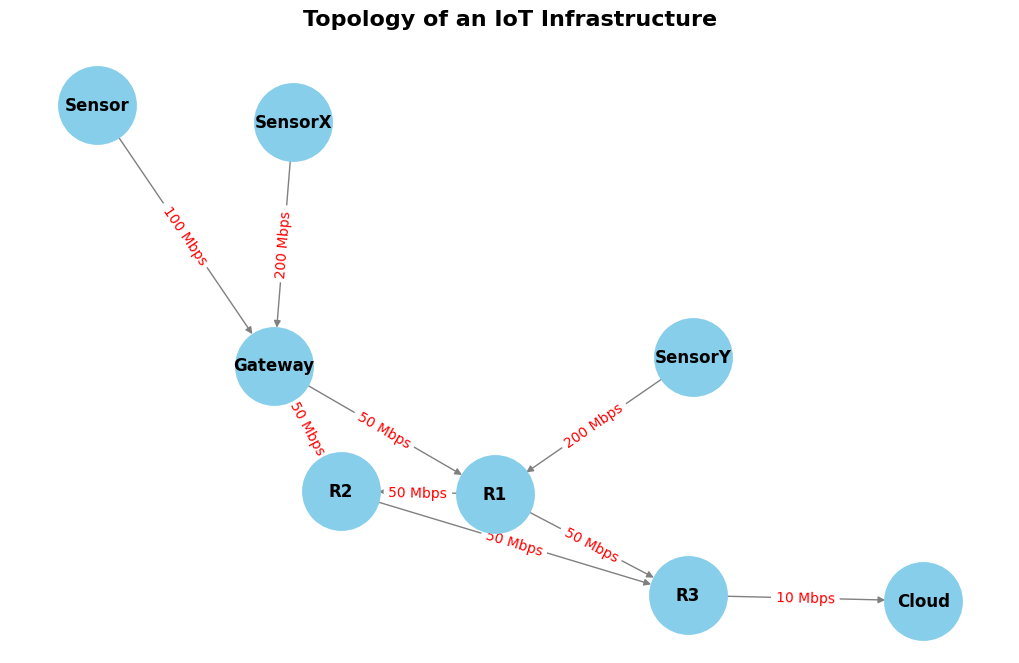

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

pos_base = nx.kamada_kawai_layout(infra)
pos = nx.spring_layout(infra, pos=pos_base, k=1.0, iterations=50, seed=42)
# Draw the network with custom styling
nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [4]:
import pandas as pd
import json
import os

# Load the JSONL file and extract metrics
json_path = "./results/json/application.jsonl"
records = []

if not os.path.exists(json_path):
    raise FileNotFoundError(f"File {json_path} not found")

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

if not records:
    raise ValueError("The JSONL file is empty or does not contain valid metrics.")

df_raw = pd.DataFrame(records)

# Extract Step, Packet_ID, Hop_ID and Field from the metric naming convention
extracted = df_raw['metric'].str.extract(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.*)')

df_raw['Step'] = extracted[0].astype(float)
df_raw['Packet_ID'] = extracted[1].astype(float)
df_raw['Hop_ID'] = extracted[2].astype(float)
df_raw['Field'] = extracted[3]

# Filter the DataFrame to keep only rows that have valid Packet_IDs (i.e., those that match the expected pattern)
df_hops = df_raw.dropna(subset=['Packet_ID']).copy()

# Convert the relevant columns to integers
df_hops['Step'] = df_hops['Step'].astype(int)
df_hops['Packet_ID'] = df_hops['Packet_ID'].astype(int)
df_hops['Hop_ID'] = df_hops['Hop_ID'].astype(int)

# Group by Step, Packet_ID, and Hop_ID
df_pivot = df_hops.pivot_table(
    index=['Step', 'Packet_ID', 'Hop_ID'],
    columns='Field',
    values='val',
    aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# Security check: if the 'hop' string is not in the JSON due to ECLYPSE limitations, add a default value
if 'hop' not in df_pivot.columns:
    df_pivot['hop'] = "Route N/A"

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")

# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next').dropna(subset=['arrival_at_next'])

for _, row in df_log.iterrows():
    # Extract the route name from the 'hop' field, which is expected to be a string like "Sensor->Gateway"
    route_name = str(row['hop'])

    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Step: {row['Step']:<3} | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {route_name:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms")


--- Chronological Log of Hops ---
[Arrival:  0.7650 ms] | Step: 1   | Pkt: 13  (Hop 1) | Route: SensorX->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.7650 ms] | Step: 1   | Pkt: 19  (Hop 1) | Route: SensorY->R1     | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.8250 ms] | Step: 1   | Pkt: 14  (Hop 1) | Route: SensorX->Gateway | Queue:  2 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.8250 ms] | Step: 1   | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.8250 ms] | Step: 1   | Pkt: 20  (Hop 1) | Route: SensorY->R1     | Queue:  2 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.8850 ms] | Step: 1   | Pkt: 21  (Hop 1) | Route: SensorY->R1     | Queue:  3 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.8850 ms] | Step: 1   | Pkt: 15  (Hop 1) | Route: SensorX->Gateway | Queue:  3 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.9450 ms] | Step: 1   | Pkt: 16  (Hop 1) | Route: SensorX->Gateway | Queue:  4 pkt | Delay Queue: 0.1800 ms
[Arrival:

# Failure recovery

In [5]:
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import random
random.seed(42)

In [6]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingExecutionEvent
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from fault_injection import FaultInjectionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")
infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node, processing_time = 0.0001)  # 0.1 ms processing time for all nodes

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)
# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge(
    "Sensor1", "Cloud1", packet_size_bytes=1500, avg_packets_per_step=2, bandwidth=0, latency=1000
)

packet_event = PacketGenerationEvent()
traffic_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
traffic_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=101,
    step_every_ms=500,
    path="./results-20260511_160749",
    events=[packet_event, traffic_event, traffic_metric, FaultInjectionEvent],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({"Sensor1": "Sensor", "Cloud1": "Cloud"})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
3. Initializing Simulation...
18:06:57.964 | INFO | VideoApp - Added flow Sensor1->Cloud1: ~2 pkt/step (avg), size 1500B


18:06:57.981 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results-20260511_160749 | remote=False | step_every_ms=500 | max_steps=101 | seed=42 | report_format=json | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
18:06:57.981 | ECLYPSE | Simulation - Simulation started.
18:06:57.984 | INFO | IoT_Network - Sensor order: [1 (APP), 2 (APP)]
18:06:57.983 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
18:06:57.983 | ECLYPSE | Simulation - Simulation step | step=1
18:06:58.484 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
18:06:58.485 | INFO | IoT_Network - Sensor order: [3 (APP), 4 (APP), 5 (APP), 6 (APP)]
18:06:58.486 | INFO | IoT_Network - Gateway order: [1 (Sensor), 2 (Sensor)]
18:06:58.484 | ECLYPSE | Simulation - Simulation step | step=2
18:06:58.985 | ECLY

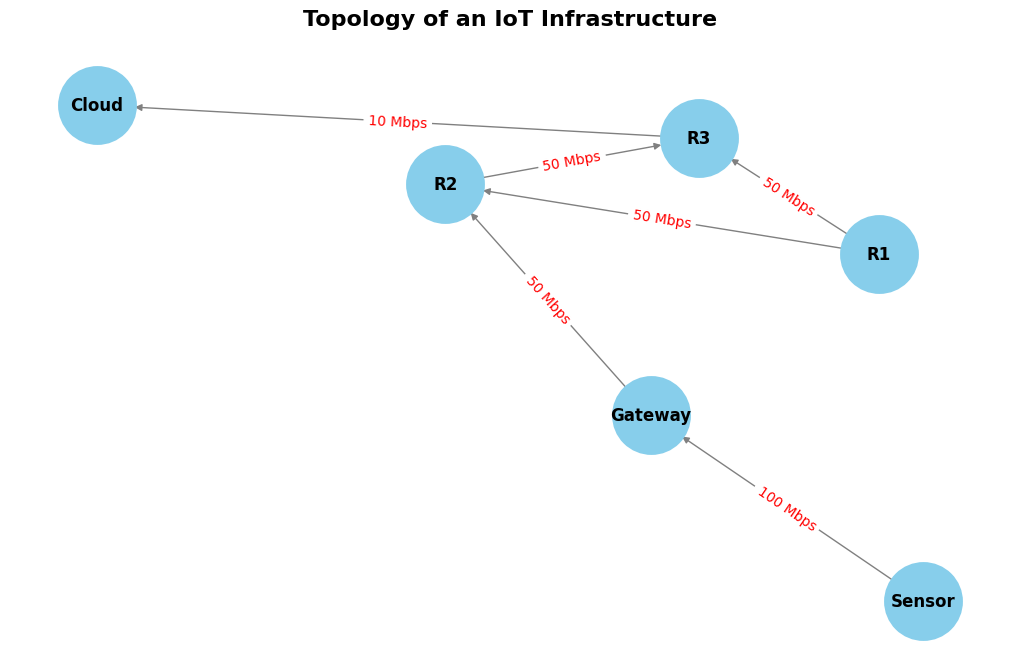

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(infra, seed=42)

nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

In [8]:
import pandas as pd
import json

# Load the JSONL file and extract metrics
json_path = "./results-20260511_160749/json/application.jsonl"
records = []

if not os.path.exists(json_path):
    raise FileNotFoundError(f"File {json_path} not found")

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

if not records:
    raise ValueError("The JSONL file is empty or does not contain valid metrics.")

df_raw = pd.DataFrame(records)

# Extract Step, Packet_ID, Hop_ID and Field from the metric naming convention
extracted = df_raw['metric'].str.extract(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.*)')

df_raw['Step'] = extracted[0].astype(float)
df_raw['Packet_ID'] = extracted[1].astype(float)
df_raw['Hop_ID'] = extracted[2].astype(float)
df_raw['Field'] = extracted[3]

# Filter the DataFrame to keep only rows that have valid Packet_IDs (i.e., those that match the expected pattern)
df_hops = df_raw.dropna(subset=['Packet_ID']).copy()

# Convert the relevant columns to integers
df_hops['Step'] = df_hops['Step'].astype(int)
df_hops['Packet_ID'] = df_hops['Packet_ID'].astype(int)
df_hops['Hop_ID'] = df_hops['Hop_ID'].astype(int)

# Group by Step, Packet_ID, and Hop_ID
df_pivot = df_hops.pivot_table(
    index=['Step', 'Packet_ID', 'Hop_ID'],
    columns='Field',
    values='val',
    aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# Security check: if the 'hop' string is not in the JSON due to ECLYPSE limitations, add a default value
if 'hop' not in df_pivot.columns:
    df_pivot['hop'] = "Route N/A"

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")

# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next').dropna(subset=['arrival_at_next'])

for _, row in df_log.iterrows():
    # Extract the route name from the 'hop' field, which is expected to be a string like "Sensor->Gateway"
    route_name = str(row['hop'])

    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Step: {row['Step']:<3} | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {route_name:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms")


--- Chronological Log of Hops ---
[Arrival:  0.8250 ms] | Step: 1   | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.9450 ms] | Step: 1   | Pkt: 2   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.3250 ms] | Step: 2   | Pkt: 3   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.4450 ms] | Step: 2   | Pkt: 4   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.4650 ms] | Step: 2   | Pkt: 1   (Hop 2) | Route: Gateway->R1     | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.5650 ms] | Step: 2   | Pkt: 5   (Hop 1) | Route: Sensor->Gateway | Queue:  3 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.6850 ms] | Step: 2   | Pkt: 6   (Hop 1) | Route: Sensor->Gateway | Queue:  4 pkt | Delay Queue: 0.3600 ms
[Arrival:  1.7050 ms] | Step: 2   | Pkt: 2   (Hop 2) | Route: Gateway->R1     | Queue:  2 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.